comensamos con la practica en pytorch con nuestros anteriores laboratorios 

In [2]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline

In [3]:
import matplotlib.pyplot as plt

In [66]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


lab2 

cargar el dataset

In [3]:
import pandas as pd

df = pd.read_csv("dataset_6/loan (1).csv")

df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [5]:
columnas_texto = df.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(df[columna].value_counts())


ApplicationDate
ApplicationDate
2018-01-01    1
2018-01-02    1
2018-01-03    1
2018-01-04    1
2018-01-05    1
             ..
2072-09-29    1
2072-09-30    1
2072-10-01    1
2072-10-02    1
2072-10-03    1
Name: count, Length: 20000, dtype: int64

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: count, dtype: int64


creamos una copia

In [6]:
# Crear una copia del dataset original
df_modelo = df.copy()

print("Dataset original:", df.shape)
print("Copia para el modelo:", df_modelo.shape)

Dataset original: (20000, 36)
Copia para el modelo: (20000, 36)


In [7]:
# Eliminar la variable que no utilizaremos
df_modelo = df_modelo.drop(columns=["ApplicationDate"])

In [8]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 35)


aplicacion del metodo one Hot encoding

In [9]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
    
]

# Convertir variables categóricas a variables numéricas
df_modelo = pd.get_dummies(
    df_modelo,
    columns=columnas_categoricas,
    dtype=int
)

In [10]:
print("Copia para el modelo:", df_modelo.shape)

Copia para el modelo: (20000, 51)


creamos las variables

In [11]:
X = df_modelo.drop("RiskScore", axis=1)
y = df_modelo["RiskScore"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (20000, 50)
Forma de y: (20000,)


80% entrenamiento 20% prueba

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 50)
X_test: (4000, 50)
y_train: (16000,)
y_test: (4000,)


intentare normalizar las variables, usando el metodo de transform

In [17]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [14]:
# Normalización utilizando nuestra función
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos los mismos parámetros a test
X_test_norm = (X_test - mu) / sigma

mandamos los datos numpy a pytorch

In [17]:
import torch

X_train_t = torch.tensor(X_train_norm.to_numpy(), dtype=torch.float32)
X_test_t = torch.tensor(X_test_norm.to_numpy(), dtype=torch.float32)

y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

In [18]:
print("X_train_t:", X_train_t.shape)
print("X_test_t:", X_test_t.shape)

print("y_train_t:", y_train_t.shape)
print("y_test_t:", y_test_t.shape)

X_train_t: torch.Size([16000, 50])
X_test_t: torch.Size([4000, 50])
y_train_t: torch.Size([16000])
y_test_t: torch.Size([4000])


In [38]:
D_in, H, D_out = X_train_t.shape[1], 100, 1

# pesos del MLP
w1 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_in+H)),
        size=(D_in, H)
    ),
    requires_grad=True,
    dtype=torch.float32
)

b1 = torch.zeros(
    H,
    requires_grad=True,
    dtype=torch.float32
)

w2 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_out+H)),
        size=(H, D_out)
    ),
    requires_grad=True,
    dtype=torch.float32
)

b2 = torch.zeros(
    D_out,
    requires_grad=True,
    dtype=torch.float32
)

epochs = 100
lr = 0.001
log_each = 10

l = []

for e in range(1, epochs + 1):

    # forward
    h = X_train_t.mm(w1) + b1

    h_relu = h.clamp(min=0)  # ReLU

    y_pred = h_relu.mm(w2) + b2

    # loss - MSE para regresión
    loss = torch.mean(
        (y_pred - y_train_t.reshape(-1, 1)) ** 2
    ) / 2

    l.append(loss.item())

    # Backprop
    loss.backward()

    with torch.no_grad():

        # update pesos
        w1 -= lr * w1.grad
        b1 -= lr * b1.grad
        w2 -= lr * w2.grad
        b2 -= lr * b2.grad

        # ponemos a cero los gradientes
        w1.grad.zero_()
        w2.grad.zero_()
        b1.grad.zero_()
        b2.grad.zero_()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {np.mean(l):.5f}"
        )
        

Epoch 10/100 Loss 1210.57335
Epoch 20/100 Loss 1064.10648
Epoch 30/100 Loss 913.31143
Epoch 40/100 Loss 768.13216
Epoch 50/100 Loss 644.19433
Epoch 60/100 Loss 547.16812
Epoch 70/100 Loss 473.28120
Epoch 80/100 Loss 416.47986
Epoch 90/100 Loss 371.82390
Epoch 100/100 Loss 335.88895


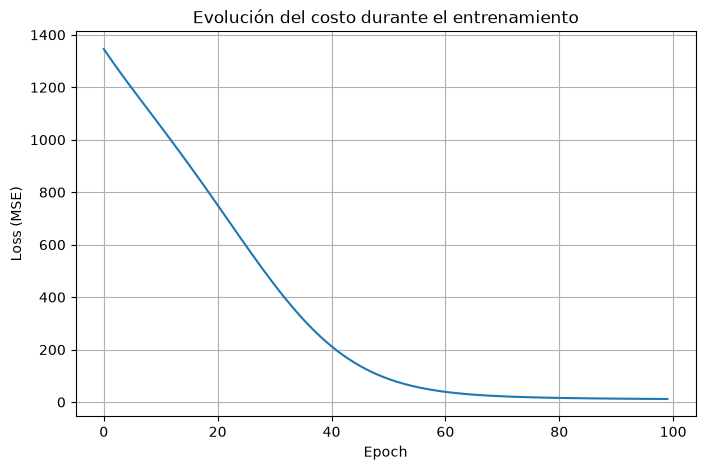

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(l)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Evolución del costo durante el entrenamiento")

plt.grid()
plt.show()

In [20]:
def evaluate(x):

    h = x.mm(w1) + b1

    h_relu = h.clamp(min=0)

    y_pred = h_relu.mm(w2) + b2

    return y_pred

In [29]:
y_pred_test = evaluate(X_test_t)

In [30]:
print(y_pred_test.shape)

torch.Size([4000, 1])


In [31]:
for i in range(10):

    print(
        f"Real: {y_test_t[i].item():.2f} "
        f"| Predicción: {y_pred_test[i].item():.2f}"
    )

Real: 41.60 | Predicción: 40.62
Real: 38.40 | Predicción: 39.95
Real: 53.00 | Predicción: 53.73
Real: 50.00 | Predicción: 54.12
Real: 51.00 | Predicción: 49.60
Real: 47.00 | Predicción: 46.61
Real: 52.00 | Predicción: 52.25
Real: 46.00 | Predicción: 46.38
Real: 69.00 | Predicción: 67.18
Real: 55.00 | Predicción: 55.02


In [40]:
test_loss = torch.mean(
    (y_pred_test - y_test_t.reshape(-1, 1)) ** 2
)

print("Test MSE:", test_loss.item())

Test MSE: 3.989837169647217


In [43]:
from sklearn.metrics import r2_score

# Predicciones
y_pred_test = evaluate(X_test_t)

# MSE
test_mse = torch.mean(
    (y_pred_test - y_test_t.reshape(-1, 1)) ** 2
)

# RMSE
test_rmse = torch.sqrt(test_mse)

# R²
y_real = y_test_t.numpy()
y_pred = y_pred_test.detach().cpu().numpy().reshape(-1)

r2 = r2_score(y_real, y_pred)

print(f"Test MSE:  {test_mse.item():.4f}")
print(f"Test RMSE: {test_rmse.item():.4f}")
print(f"R²:        {r2:.4f}")
print(f"Variabilidad explicada: {r2 * 100:.2f}%")

Test MSE:  25.0805
Test RMSE: 5.0080
R²:        0.5960
Variabilidad explicada: 59.60%


laboratorio numero 3 (dataset diabetes aplicado de forma distinta)

In [6]:
import pandas as pd

df_lab3 = pd.read_csv("dataset_6/diabetes_dataset.csv")

df_lab3.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [46]:
df_lab3.shape
df_lab3.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [47]:
columnas_texto = df_lab3.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(df_lab3[columna].value_counts())


gender
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

ethnicity
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

education_level
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

income_level
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

employment_status
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

smoking_status
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

diabetes_stage
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


aplicamos One hot encoding

In [7]:
# Crear una copia del dataset original
datos_modelo_lab3_c = df_lab3.copy()

print("Dataset original:", df_lab3.shape)
print("Copia para el modelo:", datos_modelo_lab3_c.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


In [8]:
# Eliminar la variable que no utilizaremos
datos_modelo_lab3_c = datos_modelo_lab3_c.drop(columns=["diabetes_stage", "diagnosed_diabetes", "diabetes_risk_score"])

In [10]:
print("Copia para el modelo:", datos_modelo_lab3_c.shape)

Copia para el modelo: (100000, 28)


In [11]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

# Convertir variables categóricas a variables numéricas
datos_modelo_lab3_c = pd.get_dummies(
    datos_modelo_lab3_c,
    columns=columnas_categoricas,
    dtype=int
)

In [12]:
print("Copia para el modelo:", datos_modelo_lab3_c.shape)

Copia para el modelo: (100000, 46)


In [13]:
datos_modelo_lab3_c.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

cargamos las variables

In [14]:
X = datos_modelo_lab3_c.drop("hba1c", axis=1)
y = datos_modelo_lab3_c["hba1c"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (100000, 45)
Forma de y: (100000,)


80% train 20% test

In [15]:
from sklearn.model_selection import train_test_split

X_train_l3, X_test_l3, y_train_l3, y_test_l3 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train_l3:", X_train_l3.shape)
print("X_test_l3:", X_test_l3.shape)
print("y_train_l3:", y_train_l3.shape)
print("y_test_l3:", y_test_l3.shape)

X_train_l3: (80000, 45)
X_test_l3: (20000, 45)
y_train_l3: (80000,)
y_test_l3: (20000,)


In [18]:
# Normalización utilizando nuestra función
X_train_l3_norm, mu_l3, sigma_l3 = featureNormalize(X_train_l3)

# Aplicamos los mismos parámetros a test
X_test_l3_norm = (X_test_l3 - mu_l3) / sigma_l3

cabiamos a tensor

In [19]:
import torch

X_train_l3_t = torch.tensor(
    X_train_l3_norm.to_numpy(),
    dtype=torch.float32
)

X_test_l3_t = torch.tensor(
    X_test_l3_norm.to_numpy(),
    dtype=torch.float32
)

y_train_l3_t = torch.tensor(
    y_train_l3.to_numpy(),
    dtype=torch.float32
)

y_test_l3_t = torch.tensor(
    y_test_l3.to_numpy(),
    dtype=torch.float32
)

In [69]:
print("X_train_t:", X_train_l3_t.shape)
print("X_test_t:", X_test_l3_t.shape)

print("y_train_t:", y_train_l3_t.shape)
print("y_test_t:", y_test_l3_t.shape)

X_train_t: torch.Size([80000, 45])
X_test_t: torch.Size([20000, 45])
y_train_t: torch.Size([80000])
y_test_t: torch.Size([20000])


In [20]:
D_in, H, D_out = X_train_l3_t.shape[1], 100, 1

# pesos del MLP
w1_l3 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_in+H)),
        size=(D_in, H)
    ),
    requires_grad=True,
    dtype=torch.float32
)

b1_l3 = torch.zeros(
    H,
    requires_grad=True,
    dtype=torch.float32
)

w2_l3 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_out+H)),
        size=(H, D_out)
    ),
    requires_grad=True,
    dtype=torch.float32
)

b2_l3 = torch.zeros(
    D_out,
    requires_grad=True,
    dtype=torch.float32
)

epochs = 400
lr = 0.001
log_each = 10

l_l3 = []

for e in range(1, epochs + 1):

    # forward
    h_l3 = X_train_l3_t.mm(w1_l3) + b1_l3

    h_relu_l3 = h_l3.clamp(min=0)  # ReLU

    y_pred_l3 = h_relu_l3.mm(w2_l3) + b2_l3

    # loss - MSE para regresión
    loss_l3 = torch.mean(
        (y_pred_l3 - y_train_l3_t.reshape(-1, 1)) ** 2
    ) / 2

    l_l3.append(loss_l3.item())

    # Backprop
    loss_l3.backward()

    with torch.no_grad():

        # update pesos
        w1_l3 -= lr * w1_l3.grad
        b1_l3 -= lr * b1_l3.grad
        w2_l3 -= lr * w2_l3.grad
        b2_l3 -= lr * b2_l3.grad

        # ponemos a cero los gradientes
        w1_l3.grad.zero_()
        w2_l3.grad.zero_()
        b1_l3.grad.zero_()
        b2_l3.grad.zero_()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {np.mean(l_l3):.5f}"
        )

Epoch 10/400 Loss 20.61957
Epoch 20/400 Loss 18.51323
Epoch 30/400 Loss 16.70883
Epoch 40/400 Loss 15.15569
Epoch 50/400 Loss 13.81341
Epoch 60/400 Loss 12.64916
Epoch 70/400 Loss 11.63587
Epoch 80/400 Loss 10.75100
Epoch 90/400 Loss 9.97563
Epoch 100/400 Loss 9.29383
Epoch 110/400 Loss 8.69214
Epoch 120/400 Loss 8.15917
Epoch 130/400 Loss 7.68526
Epoch 140/400 Loss 7.26222
Epoch 150/400 Loss 6.88311
Epoch 160/400 Loss 6.54204
Epoch 170/400 Loss 6.23399
Epoch 180/400 Loss 5.95471
Epoch 190/400 Loss 5.70056
Epoch 200/400 Loss 5.46845
Epoch 210/400 Loss 5.25572
Epoch 220/400 Loss 5.06011
Epoch 230/400 Loss 4.87966
Epoch 240/400 Loss 4.71269
Epoch 250/400 Loss 4.55775
Epoch 260/400 Loss 4.41358
Epoch 270/400 Loss 4.27908
Epoch 280/400 Loss 4.15330
Epoch 290/400 Loss 4.03540
Epoch 300/400 Loss 3.92465
Epoch 310/400 Loss 3.82039
Epoch 320/400 Loss 3.72208
Epoch 330/400 Loss 3.62918
Epoch 340/400 Loss 3.54126
Epoch 350/400 Loss 3.45791
Epoch 360/400 Loss 3.37878
Epoch 370/400 Loss 3.30354
Ep

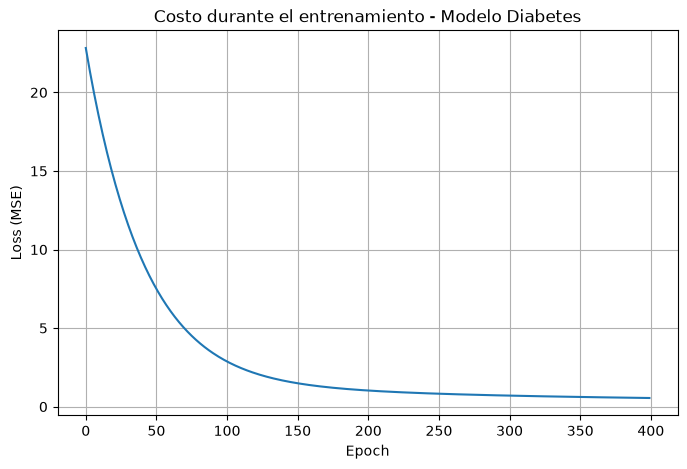

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(l_l3)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Costo durante el entrenamiento - Modelo Diabetes")

plt.grid()
plt.show()

In [22]:
def evaluate_l3(x):

    h_l3 = x.mm(w1_l3) + b1_l3

    h_relu_l3 = h_l3.clamp(min=0)

    y_pred_l3 = h_relu_l3.mm(w2_l3) + b2_l3

    return y_pred_l3

In [23]:
# Predicciones sobre los datos de prueba
y_pred_test_l3 = evaluate_l3(X_test_l3_t)

In [24]:
# Mostrar algunas predicciones
for i in range(10):

    print(
        f"Real: {y_test_l3_t[i].item():.2f} "
        f"| Predicción: {y_pred_test_l3[i].item():.2f}"
    )


Real: 5.41 | Predicción: 5.63
Real: 7.72 | Predicción: 6.71
Real: 6.11 | Predicción: 5.63
Real: 6.37 | Predicción: 8.46
Real: 5.35 | Predicción: 6.21
Real: 5.97 | Predicción: 6.91
Real: 6.75 | Predicción: 7.78
Real: 6.82 | Predicción: 7.08
Real: 6.96 | Predicción: 5.68
Real: 7.70 | Predicción: 7.22


In [25]:
# MSE sobre los datos de prueba
test_loss_l3 = torch.mean(
    (y_pred_test_l3 - y_test_l3_t.reshape(-1, 1)) ** 2
)

print("Test MSE:", test_loss_l3.item())

Test MSE: 1.0883718729019165


lab3 (modificacion del dataset) regresion polinomial 

usaremos el mismo dataset que en la anterior regresion, es decir el dataset se diabetes corregido para que este pensado para una regresion polinomica

In [26]:
X_poly_l3 = datos_modelo_lab3_c.drop(columns=["hba1c"])
y_poly_l3 = datos_modelo_lab3_c["hba1c"]

print("Forma de X_poly_l3:", X_poly_l3.shape)
print("Forma de y_poly_l3:", y_poly_l3.shape)

Forma de X_poly_l3: (100000, 45)
Forma de y_poly_l3: (100000,)


aplicamos formula de grado 2

In [27]:
# Convertimos X a NumPy para realizar la transformación polinómica

X_poly_l3 = X_poly_l3.to_numpy()

# Agregamos las características elevadas al cuadrado

X_poly_l3 = np.concatenate(
    [
        X_poly_l3,
        X_poly_l3 ** 2
    ],
    axis=1
)

print("Forma de X_poly_l3:", X_poly_l3.shape)

Forma de X_poly_l3: (100000, 90)


80% train 20%test

In [28]:
from sklearn.model_selection import train_test_split

X_train_poly_l3, X_test_poly_l3, y_train_poly_l3, y_test_poly_l3 = train_test_split(
    X_poly_l3,
    y_poly_l3,
    test_size=0.20,
    random_state=42
)

print("X_train_poly_l3:", X_train_poly_l3.shape)
print("X_test_poly_l3:", X_test_poly_l3.shape)
print("y_train_poly_l3:", y_train_poly_l3.shape)
print("y_test_poly_l3:", y_test_poly_l3.shape)

X_train_poly_l3: (80000, 90)
X_test_poly_l3: (20000, 90)
y_train_poly_l3: (80000,)
y_test_poly_l3: (20000,)


aplicamos la funcion de la normal

In [29]:
# Normalización utilizando nuestra función

X_train_poly_l3_norm, mu_poly_l3, sigma_poly_l3 = featureNormalize(
    X_train_poly_l3
)

# Aplicamos los mismos parámetros a test

X_test_poly_l3_norm = (
    X_test_poly_l3 - mu_poly_l3
) / sigma_poly_l3

convertimos a tensor

In [33]:
import torch

X_train_poly_l3_t = torch.tensor(
    X_train_poly_l3_norm,
    dtype=torch.float32
).cuda()

X_test_poly_l3_t = torch.tensor(
    X_test_poly_l3_norm,
    dtype=torch.float32
).cuda()

y_train_poly_l3_t = torch.tensor(
    y_train_poly_l3.to_numpy(),
    dtype=torch.float32
).cuda()

y_test_poly_l3_t = torch.tensor(
    y_test_poly_l3.to_numpy(),
    dtype=torch.float32
).cuda()

In [34]:
print("X_train_poly_l3_t:", X_train_poly_l3_t.shape)
print("X_test_poly_l3_t:", X_test_poly_l3_t.shape)
print("y_train_poly_l3_t:", y_train_poly_l3_t.shape)
print("y_test_poly_l3_t:", y_test_poly_l3_t.shape)

X_train_poly_l3_t: torch.Size([80000, 90])
X_test_poly_l3_t: torch.Size([20000, 90])
y_train_poly_l3_t: torch.Size([80000])
y_test_poly_l3_t: torch.Size([20000])


In [35]:
print(X_train_poly_l3_t.device)
print(X_test_poly_l3_t.device)
print(y_train_poly_l3_t.device)
print(y_test_poly_l3_t.device)

cuda:0
cuda:0
cuda:0
cuda:0


In [42]:
D_in, H, D_out = X_train_poly_l3_t.shape[1], 100, 1

# pesos del MLP (GPU)
w1_poly_l3 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_in + H)),
        size=(D_in, H)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b1_poly_l3 = torch.zeros(
    H,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

w2_poly_l3 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2/(D_out + H)),
        size=(H, D_out)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b2_poly_l3 = torch.zeros(
    D_out,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

epochs = 400
lr = 0.0015
log_each = 10

l_poly_l3 = []

for e in range(1, epochs + 1):

    # Forward
    h_poly_l3 = X_train_poly_l3_t.mm(w1_poly_l3) + b1_poly_l3

    h_relu_poly_l3 = h_poly_l3.clamp(min=0)  # ReLU

    y_pred_poly_l3 = h_relu_poly_l3.mm(w2_poly_l3) + b2_poly_l3

    # Loss - MSE para regresión
    loss_poly_l3 = torch.mean(
        (y_pred_poly_l3 - y_train_poly_l3_t.reshape(-1, 1)) ** 2
    ) / 2

    l_poly_l3.append(loss_poly_l3.item())

    # Backpropagation
    loss_poly_l3.backward()

    with torch.no_grad():

        # Actualizar pesos
        w1_poly_l3 -= lr * w1_poly_l3.grad
        b1_poly_l3 -= lr * b1_poly_l3.grad

        w2_poly_l3 -= lr * w2_poly_l3.grad
        b2_poly_l3 -= lr * b2_poly_l3.grad

        # Reiniciar gradientes
        w1_poly_l3.grad.zero_()
        b1_poly_l3.grad.zero_()

        w2_poly_l3.grad.zero_()
        b2_poly_l3.grad.zero_()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {np.mean(l_poly_l3):.5f}"
        )

Epoch 10/400 Loss 20.92724
Epoch 20/400 Loss 16.78148
Epoch 30/400 Loss 13.78609
Epoch 40/400 Loss 11.58055
Epoch 50/400 Loss 9.92678
Epoch 60/400 Loss 8.66333
Epoch 70/400 Loss 7.67935
Epoch 80/400 Loss 6.89819
Epoch 90/400 Loss 6.26648
Epoch 100/400 Loss 5.74669
Epoch 110/400 Loss 5.31217
Epoch 120/400 Loss 4.94372
Epoch 130/400 Loss 4.62733
Epoch 140/400 Loss 4.35258
Epoch 150/400 Loss 4.11163
Epoch 160/400 Loss 3.89849
Epoch 170/400 Loss 3.70849
Epoch 180/400 Loss 3.53798
Epoch 190/400 Loss 3.38403
Epoch 200/400 Loss 3.24427
Epoch 210/400 Loss 3.11678
Epoch 220/400 Loss 2.99998
Epoch 230/400 Loss 2.89254
Epoch 240/400 Loss 2.79336
Epoch 250/400 Loss 2.70150
Epoch 260/400 Loss 2.61616
Epoch 270/400 Loss 2.53666
Epoch 280/400 Loss 2.46240
Epoch 290/400 Loss 2.39287
Epoch 300/400 Loss 2.32764
Epoch 310/400 Loss 2.26630
Epoch 320/400 Loss 2.20851
Epoch 330/400 Loss 2.15396
Epoch 340/400 Loss 2.10239
Epoch 350/400 Loss 2.05356
Epoch 360/400 Loss 2.00725
Epoch 370/400 Loss 1.96326
Epoch 

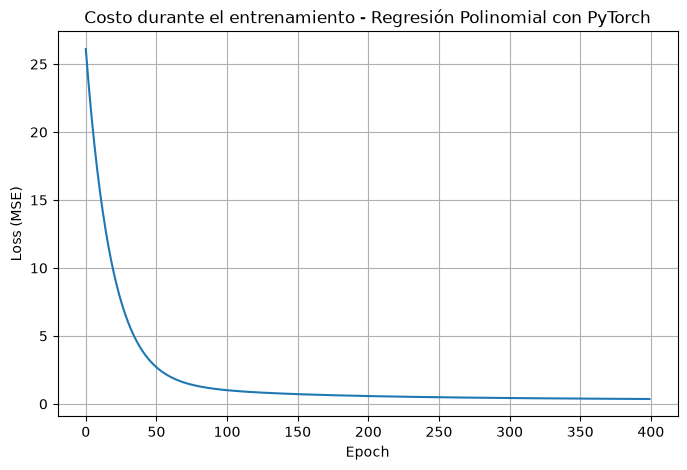

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(l_poly_l3)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Costo durante el entrenamiento - Regresión Polinomial con PyTorch")

plt.grid()
plt.show()

In [44]:
def evaluate_poly_l3(x):

    h_poly_l3 = x.mm(w1_poly_l3) + b1_poly_l3

    h_relu_poly_l3 = h_poly_l3.clamp(min=0)

    y_pred_poly_l3 = h_relu_poly_l3.mm(w2_poly_l3) + b2_poly_l3

    return y_pred_poly_l3

In [45]:
# Predicciones sobre los datos de prueba
y_pred_test_poly_l3 = evaluate_poly_l3(X_test_poly_l3_t)

# Mostrar algunas predicciones
for i in range(10):

    print(
        f"Real: {y_test_poly_l3_t[i].item():.2f} "
        f"| Predicción: {y_pred_test_poly_l3[i].item():.2f}"
    )

Real: 5.41 | Predicción: 5.54
Real: 7.72 | Predicción: 6.70
Real: 6.11 | Predicción: 6.77
Real: 6.37 | Predicción: 7.16
Real: 5.35 | Predicción: 5.40
Real: 5.97 | Predicción: 5.82
Real: 6.75 | Predicción: 6.94
Real: 6.82 | Predicción: 7.58
Real: 6.96 | Predicción: 6.21
Real: 7.70 | Predicción: 7.85


In [46]:
# MSE sobre los datos de prueba
test_loss_poly_l3 = torch.mean(
    (y_pred_test_poly_l3 - y_test_poly_l3_t.reshape(-1, 1)) ** 2
)

print("Test MSE:", test_loss_poly_l3.item())

Test MSE: 0.7087490558624268


lab 4 mismo dataset de diabetes sin embargo ahora usado de la manera correcta para una regresion de tipo clasificacion binaria

tratamiento del dataset 

In [47]:
import pandas as pd

df_lab4 = pd.read_csv("dataset_6/diabetes_dataset.csv")

df_lab4.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [50]:
df_lab4.shape
df_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [51]:
# Crear una copia del dataset original
datos_modelo_lab4 = df_lab4.copy()

print("Dataset original:", df_lab4.shape)
print("Copia para el modelo:", datos_modelo_lab4.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


In [52]:
# Eliminar la variable que no utilizaremos
datos_modelo_lab4 = datos_modelo_lab4.drop(columns=["diabetes_stage",])

In [53]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 30)


aplicamos One Hot encoding

In [54]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

# Convertir variables categóricas a variables numéricas
datos_modelo_lab4 = pd.get_dummies(
    datos_modelo_lab4,
    columns=columnas_categoricas,
    dtype=int
)

In [55]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 48)


In [56]:
datos_modelo_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

cargamos las variables

In [58]:
X_lab4 = datos_modelo_lab4.drop(columns=["diagnosed_diabetes"])
y_lab4 = datos_modelo_lab4["diagnosed_diabetes"]

print("Forma de X:", X_lab4.shape)
print("Forma de y:", y_lab4.shape)

print("\nDistribución de clases:")
print(y_lab4.value_counts())

Forma de X: (100000, 47)
Forma de y: (100000,)

Distribución de clases:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


80% train 20% test

In [59]:
from sklearn.model_selection import train_test_split

X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_lab4,
    y_lab4,
    test_size=0.20,
    random_state=42,
    stratify=y_lab4
)

print("X_train:", X_train_lab4.shape)
print("X_test:", X_test_lab4.shape)
print("y_train:", y_train_lab4.shape)
print("y_test:", y_test_lab4.shape)

X_train: (80000, 47)
X_test: (20000, 47)
y_train: (80000,)
y_test: (20000,)


In [60]:
print("Distribución original:")
print(y_lab4.value_counts())
print(y.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train_lab4.value_counts())
print(y_train_lab4.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test_lab4.value_counts())
print(y_test_lab4.value_counts(normalize=True))

Distribución original:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64
hba1c
6.48    0.00525
6.51    0.00524
6.25    0.00519
6.64    0.00516
6.54    0.00515
         ...   
9.29    0.00001
9.80    0.00001
9.14    0.00001
9.20    0.00001
9.24    0.00001
Name: proportion, Length: 548, dtype: float64

Distribución en TRAIN:
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64
diagnosed_diabetes
1    0.599975
0    0.400025
Name: proportion, dtype: float64

Distribución en TEST:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64
diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


metodo smote

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.95, random_state=42)

X_train_lab4, y_train_lab4 = smote.fit_resample(
    X_train_lab4,
    y_train_lab4
)

print("Después de SMOTE:")
print("X_train:", X_train_lab4.shape)
print("y_train:", y_train_lab4.shape)

print("\nDistribución de clases:")
print(y_train_lab4.value_counts())

Después de SMOTE:
X_train: (93596, 47)
y_train: (93596,)

Distribución de clases:
diagnosed_diabetes
1    47998
0    45598
Name: count, dtype: int64


aplicamos la funcion de normalizacion

In [62]:
X_train_lab4_norm, mu_lab4, sigma_lab4 = featureNormalize(
    X_train_lab4
)

X_test_lab4_norm = (
    X_test_lab4 - mu_lab4
) / sigma_lab4

funcion sigmoID Y bynari cross entropy para pytorch

In [63]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [91]:
def binary_cross_entropy(output, target):

    epsilon = 1e-7

    output = torch.clamp(
        output,
        epsilon,
        1 - epsilon
    )

    loss = -(
        target * torch.log(output)
        + (1 - target) * torch.log(1 - output)
    )

    return loss.mean()

transformamos a tensor y llevamos a cuda

In [92]:
import torch

X_train_lab4_t = torch.tensor(
    X_train_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

X_test_lab4_t = torch.tensor(
    X_test_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

y_train_lab4_t = torch.tensor(
    y_train_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

y_test_lab4_t = torch.tensor(
    y_test_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

In [137]:
D_in, H, D_out = X_train_lab4_t.shape[1], 100, 1

# Pesos de la primera capa
w1_lab4 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2 / (D_in + H)),
        size=(D_in, H)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b1_lab4 = torch.zeros(
    H,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

# Pesos de la segunda capa
w2_lab4 = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2 / (D_out + H)),
        size=(H, D_out)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b2_lab4 = torch.zeros(
    D_out,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)
epochs = 6000
lr = 0.05
log_each = 10

l_lab4 = []

for e in range(1, epochs + 1):

    # Forward
    h_lab4 = X_train_lab4_t.mm(w1_lab4) + b1_lab4

    h_relu_lab4 = h_lab4.clamp(min=0)  # ReLU

    logits_lab4 = h_relu_lab4.mm(w2_lab4) + b2_lab4

    # Convertimos el logit en probabilidad
    y_pred_lab4 = sigmoid(logits_lab4)

    # Loss - Binary Cross Entropy
    loss_lab4 = binary_cross_entropy(
        y_pred_lab4,
        y_train_lab4_t.reshape(-1, 1)
    )

    l_lab4.append(loss_lab4.item())

    # Backpropagation
    loss_lab4.backward()

    with torch.no_grad():

        # Actualizamos los pesos
        w1_lab4 -= lr * w1_lab4.grad
        b1_lab4 -= lr * b1_lab4.grad

        w2_lab4 -= lr * w2_lab4.grad
        b2_lab4 -= lr * b2_lab4.grad

        # Reiniciamos los gradientes
        w1_lab4.grad.zero_()
        b1_lab4.grad.zero_()

        w2_lab4.grad.zero_()
        b2_lab4.grad.zero_()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_lab4.item():.5f}"
        )

Epoch 10/6000 Loss 0.69563
Epoch 20/6000 Loss 0.58094
Epoch 30/6000 Loss 0.51659
Epoch 40/6000 Loss 0.47472
Epoch 50/6000 Loss 0.44514
Epoch 60/6000 Loss 0.42308
Epoch 70/6000 Loss 0.40601
Epoch 80/6000 Loss 0.39245
Epoch 90/6000 Loss 0.38145
Epoch 100/6000 Loss 0.37237
Epoch 110/6000 Loss 0.36478
Epoch 120/6000 Loss 0.35837
Epoch 130/6000 Loss 0.35289
Epoch 140/6000 Loss 0.34816
Epoch 150/6000 Loss 0.34405
Epoch 160/6000 Loss 0.34045
Epoch 170/6000 Loss 0.33728
Epoch 180/6000 Loss 0.33446
Epoch 190/6000 Loss 0.33194
Epoch 200/6000 Loss 0.32966
Epoch 210/6000 Loss 0.32760
Epoch 220/6000 Loss 0.32573
Epoch 230/6000 Loss 0.32401
Epoch 240/6000 Loss 0.32242
Epoch 250/6000 Loss 0.32095
Epoch 260/6000 Loss 0.31958
Epoch 270/6000 Loss 0.31830
Epoch 280/6000 Loss 0.31709
Epoch 290/6000 Loss 0.31595
Epoch 300/6000 Loss 0.31487
Epoch 310/6000 Loss 0.31383
Epoch 320/6000 Loss 0.31285
Epoch 330/6000 Loss 0.31190
Epoch 340/6000 Loss 0.31099
Epoch 350/6000 Loss 0.31010
Epoch 360/6000 Loss 0.30925
E

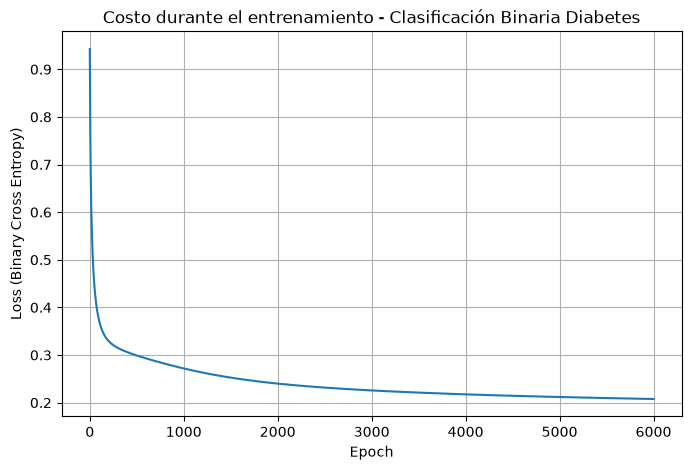

In [138]:
plt.figure(figsize=(8, 5))

plt.plot(l_lab4)

plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Costo durante el entrenamiento - Clasificación Binaria Diabetes")

plt.grid()
plt.show()

In [139]:
def evaluate_lab4(x):

    # Forward
    h_lab4 = x.mm(w1_lab4) + b1_lab4

    h_relu_lab4 = h_lab4.clamp(min=0)

    logits_lab4 = h_relu_lab4.mm(w2_lab4) + b2_lab4

    # Convertimos el logit en probabilidad
    y_probas_lab4 = sigmoid(logits_lab4)

    return y_probas_lab4

In [140]:
y_probas_test_lab4 = evaluate_lab4(X_test_lab4_t)

for i in range(10):

    print(
        f"Real: {y_test_lab4_t[i].item():.0f} "
        f"| Probabilidad: {y_probas_test_lab4[i].item():.4f}"
    )

Real: 0 | Probabilidad: 0.1859
Real: 1 | Probabilidad: 0.9996
Real: 0 | Probabilidad: 0.1156
Real: 0 | Probabilidad: 0.0988
Real: 1 | Probabilidad: 1.0000
Real: 0 | Probabilidad: 0.1858
Real: 0 | Probabilidad: 0.1891
Real: 1 | Probabilidad: 0.7554
Real: 0 | Probabilidad: 0.2244
Real: 1 | Probabilidad: 0.9964


In [141]:
y_pred_test_lab4 = (
    y_probas_test_lab4 >= 0.5
).float()

In [130]:
for i in range(10):

    print(
        f"Real: {y_test_lab4_t[i].item():.0f} "
        f"| Probabilidad: {y_probas_test_lab4[i].item():.4f} "
        f"| Predicción: {y_pred_test_lab4[i].item():.0f}"
    )

Real: 0 | Probabilidad: 0.2418 | Predicción: 0
Real: 1 | Probabilidad: 0.9972 | Predicción: 1
Real: 0 | Probabilidad: 0.1155 | Predicción: 0
Real: 0 | Probabilidad: 0.1455 | Predicción: 0
Real: 1 | Probabilidad: 0.9995 | Predicción: 1
Real: 0 | Probabilidad: 0.2183 | Predicción: 0
Real: 0 | Probabilidad: 0.2419 | Predicción: 0
Real: 1 | Probabilidad: 0.7459 | Predicción: 1
Real: 0 | Probabilidad: 0.1489 | Predicción: 0
Real: 1 | Probabilidad: 0.9548 | Predicción: 1


In [142]:
accuracy_lab4 = (
    (y_pred_test_lab4 == y_test_lab4_t.reshape(-1, 1))
    .float()
    .mean()
)

print(f"Accuracy: {accuracy_lab4.item() * 100:.2f}%")

Accuracy: 90.32%


que esta pesadilla acabe por favor 

lab 5 modelo grafico 

In [148]:
import random

In [144]:
df_emnist = pd.read_csv(
    "dataset_6/emnist-balanced-train.csv",
    header=None
)

print("Forma del dataset:", df_emnist.shape)

Forma del dataset: (112800, 785)


creacion de variables 

vizualizacion

80% train y 20% test

In [150]:
datos_modelo_emnist = df_emnist.copy()

print("Dataset original:", df_emnist.shape)
print("Copia para el modelo:", datos_modelo_emnist.shape)

Dataset original: (112800, 785)
Copia para el modelo: (112800, 785)


In [151]:
X_emnist = datos_modelo_emnist.iloc[:, 1:]
y_emnist = datos_modelo_emnist.iloc[:, 0]

print("Forma de X:", X_emnist.shape)
print("Forma de y:", y_emnist.shape)

Forma de X: (112800, 784)
Forma de y: (112800,)


In [152]:
X_emnist = X_emnist.to_numpy()
y_emnist = y_emnist.to_numpy()

In [153]:
from sklearn.model_selection import train_test_split

X_train_emnist, X_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    X_emnist,
    y_emnist,
    test_size=0.20,
    random_state=42,
    stratify=y_emnist
)

print("X_train:", X_train_emnist.shape)
print("y_train:", y_train_emnist.shape)
print("X_test:", X_test_emnist.shape)
print("y_test:", y_test_emnist.shape)

X_train: (90240, 784)
y_train: (90240,)
X_test: (22560, 784)
y_test: (22560,)


visualizacion

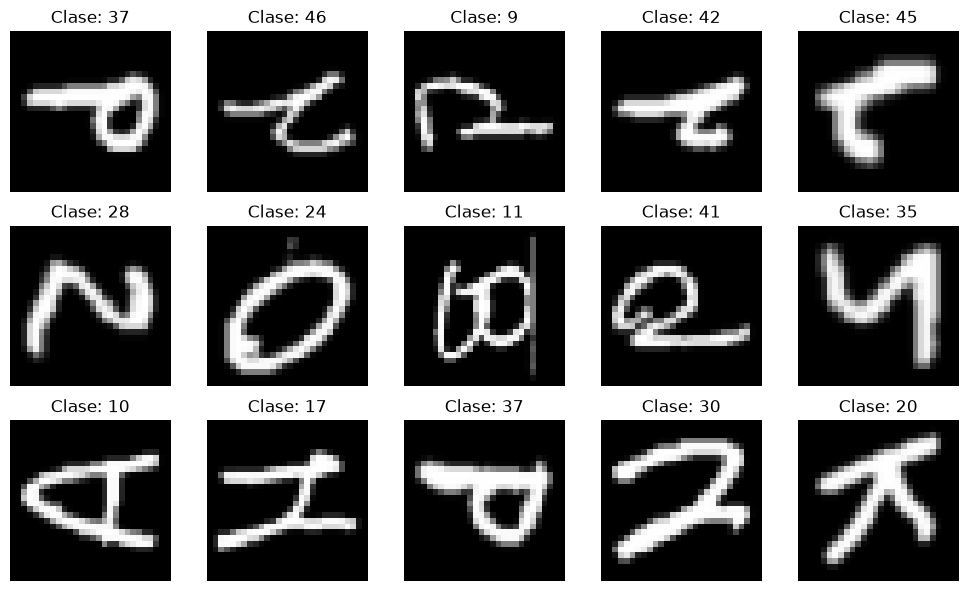

In [156]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

normalizacion

In [157]:
# Normalizamos los píxeles
X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0

# Convertimos las etiquetas a enteros
y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)

funcion de perdida y derivada

In [158]:
# Funciones para clasificación multiclase

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(
        axis=-1,
        keepdims=True
    )


def cross_entropy(output, target):

    logits = output[
        torch.arange(len(output)),
        target
    ]

    loss = -logits + torch.log(
        torch.sum(torch.exp(output), axis=-1)
    )

    loss = loss.mean()

    return loss

In [159]:
import torch

X_train_emnist_t = torch.from_numpy(
    X_train_emnist
).float().cuda()

X_test_emnist_t = torch.from_numpy(
    X_test_emnist
).float().cuda()

y_train_emnist_t = torch.from_numpy(
    y_train_emnist
).long().cuda()

y_test_emnist_t = torch.from_numpy(
    y_test_emnist
).long().cuda()

In [171]:
D_in, H, D_out = X_train_emnist_t.shape[1], 100, 47

# Pesos de la primera capa
w1_emnist = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2 / (D_in + H)),
        size=(D_in, H)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b1_emnist = torch.zeros(
    H,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

# Pesos de la segunda capa
w2_emnist = torch.tensor(
    np.random.normal(
        loc=0.0,
        scale=np.sqrt(2 / (D_out + H)),
        size=(H, D_out)
    ),
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)

b2_emnist = torch.zeros(
    D_out,
    requires_grad=True,
    device="cuda",
    dtype=torch.float32
)
epochs = 6000
lr = 0.09
log_each = 10

l_emnist = []

for e in range(1, epochs + 1):

    # Forward
    h_emnist = X_train_emnist_t.mm(w1_emnist) + b1_emnist

    h_relu_emnist = h_emnist.clamp(min=0)  # ReLU

    y_pred_emnist = h_relu_emnist.mm(w2_emnist) + b2_emnist

    # Loss
    loss_emnist = cross_entropy(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Backpropagation
    loss_emnist.backward()

    with torch.no_grad():

        # Actualizar pesos
        w1_emnist -= lr * w1_emnist.grad
        b1_emnist -= lr * b1_emnist.grad

        w2_emnist -= lr * w2_emnist.grad
        b2_emnist -= lr * b2_emnist.grad

        # Reiniciar gradientes
        w1_emnist.grad.zero_()
        b1_emnist.grad.zero_()

        w2_emnist.grad.zero_()
        b2_emnist.grad.zero_()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_emnist.item():.5f}"
        )

Epoch 10/6000 Loss 3.76598
Epoch 20/6000 Loss 3.62125
Epoch 30/6000 Loss 3.47179
Epoch 40/6000 Loss 3.31040
Epoch 50/6000 Loss 3.13914
Epoch 60/6000 Loss 2.96410
Epoch 70/6000 Loss 2.79290
Epoch 80/6000 Loss 2.63201
Epoch 90/6000 Loss 2.48521
Epoch 100/6000 Loss 2.35412
Epoch 110/6000 Loss 2.23883
Epoch 120/6000 Loss 2.13831
Epoch 130/6000 Loss 2.05103
Epoch 140/6000 Loss 1.97532
Epoch 150/6000 Loss 1.90951
Epoch 160/6000 Loss 1.85210
Epoch 170/6000 Loss 1.80178
Epoch 180/6000 Loss 1.75743
Epoch 190/6000 Loss 1.71812
Epoch 200/6000 Loss 1.68305
Epoch 210/6000 Loss 1.65160
Epoch 220/6000 Loss 1.62323
Epoch 230/6000 Loss 1.59752
Epoch 240/6000 Loss 1.57408
Epoch 250/6000 Loss 1.55264
Epoch 260/6000 Loss 1.53293
Epoch 270/6000 Loss 1.51475
Epoch 280/6000 Loss 1.49792
Epoch 290/6000 Loss 1.48227
Epoch 300/6000 Loss 1.46767
Epoch 310/6000 Loss 1.45403
Epoch 320/6000 Loss 1.44122
Epoch 330/6000 Loss 1.42918
Epoch 340/6000 Loss 1.41782
Epoch 350/6000 Loss 1.40708
Epoch 360/6000 Loss 1.39690
E

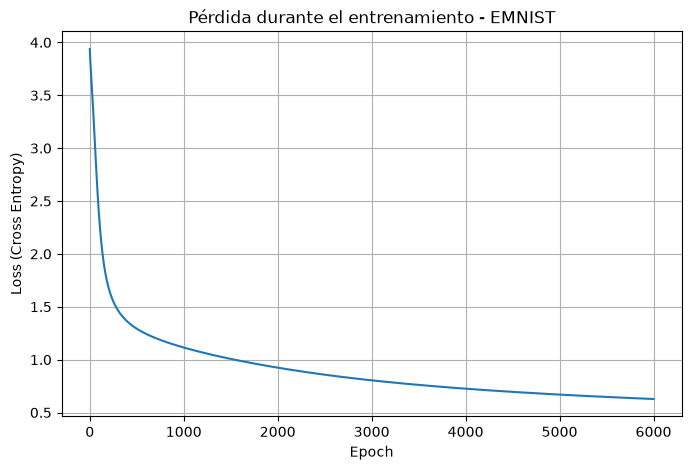

In [172]:
plt.figure(figsize=(8, 5))

plt.plot(l_emnist)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.title("Pérdida durante el entrenamiento - EMNIST")

plt.grid()

plt.show()

In [164]:
def evaluate_emnist(x):

    # Forward
    h_emnist = x.mm(w1_emnist) + b1_emnist

    h_relu_emnist = h_emnist.clamp(min=0)

    logits_emnist = h_relu_emnist.mm(w2_emnist) + b2_emnist

    # Convertimos logits en probabilidades
    y_probas_emnist = softmax(logits_emnist)

    # Elegimos la clase con mayor probabilidad
    return torch.argmax(y_probas_emnist, axis=1)

In [173]:
from sklearn.metrics import accuracy_score

y_pred_emnist = evaluate_emnist(X_test_emnist_t)

accuracy_emnist = accuracy_score(
    y_test_emnist,
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist:.4f}")
print(f"Porcentaje de acierto: {accuracy_emnist * 100:.2f}%")

Accuracy: 0.7894
Porcentaje de acierto: 78.94%


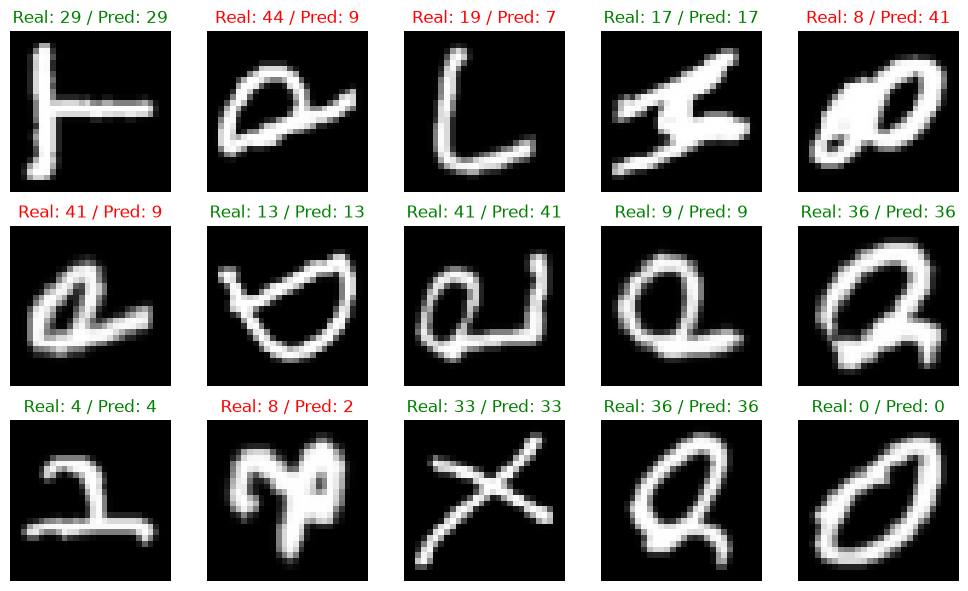

In [174]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]

        y_real = y_test_emnist[ix]

        y_pred = evaluate_emnist(
            torch.tensor(
                [img],
                dtype=torch.float32,
                device="cuda"
            )
        )[0].item()

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()